# Hiring Prediction Project

This notebook implements data analysis and machine learning techniques to predict hiring based on factors like gender, education, and age.

## 1. Data Loading and Overview

In [1]:

import pandas as pd

# Load datasets
file_path = "../data/Salary_Data.csv"  # Replace with your actual file path
data = pd.read_csv(file_path)

# Display dataset overview
print("Dataset Overview:\n", data.head())


Dataset Overview:
     Age  Gender Education Level          Job Title  Years of Experience  \
0  32.0    Male      Bachelor's  Software Engineer                  5.0   
1  28.0  Female        Master's       Data Analyst                  3.0   
2  45.0    Male             PhD     Senior Manager                 15.0   
3  36.0  Female      Bachelor's    Sales Associate                  7.0   
4  52.0    Male        Master's           Director                 20.0   

     Salary  
0   90000.0  
1   65000.0  
2  150000.0  
3   60000.0  
4  200000.0  


## 2. Modularizing Code into Classes and Methods

In [2]:

class HiringPredictionPipeline:
    def __init__(self, data):
        self.data = data
        self.clean_data = None
    
    def preprocess_data(self):
        # Handle missing values
        self.clean_data = self.data.dropna()
        print("Preprocessed data shape:", self.clean_data.shape)
    
    def calculate_pearson_correlation(self, feature1, feature2):
        correlation = self.clean_data[feature1].corr(self.clean_data[feature2])
        print(f"Pearson Correlation between {feature1} and {feature2}: {correlation}")
        return correlation


## 3. Pearson's Correlation Analysis

In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

class LinearRegressionPipeline:
    def __init__(self, data):
        if isinstance(data, pd.DataFrame):
            self.data = data
        else:
            raise ValueError("Provided data is not a Pandas DataFrame")
        self.model = None
        self.X = None
        self.y = None
        self.scaler = StandardScaler()

    def load_data(self):
        """Loads data into the pipeline."""
        print("Data loaded successfully. Here are the first few rows:")
        print(self.data.head())
        return self.data

    def clean_data(self):
        """Cleans the data by selecting relevant columns and removing any missing values."""
        if not isinstance(self.data, pd.DataFrame):
            raise ValueError("Data is not a Pandas DataFrame. Please check the data source.")
        
        print(f"Columns available in the dataset: {self.data.columns.tolist()}")

        # Convert Gender to numerical format: Male = 1, Female = 2
        self.data['Gender'] = self.data['Gender'].map({'Male': 1, 'Female': 2})

        # Replace similar education levels to have uniformity using .loc
        self.data.loc[:, 'Education Level'] = self.data['Education Level'].replace({
            "Bachelor's Degree": "Bachelor's",
            "Master's Degree": "Master's",
            "PhD": "phD"
        })

        # Drop rows with missing values
        self.data.dropna(inplace=True)

        # Optionally, check for duplicates
        self.data.drop_duplicates(inplace=True)

        print(f"Data cleaned with shape: {self.data.shape}")
        return self.data

    def remove_outliers(self, columns, method='iqr'):
        """Removes outliers from the dataset for the specified columns using the chosen method."""
        if method == 'iqr':
            for col in columns:
                Q1 = self.data[col].quantile(0.25)
                Q3 = self.data[col].quantile(0.75)
                IQR = Q3 - Q1
                lower_bound = Q1 - 1.5 * IQR
                upper_bound = Q3 + 1.5 * IQR
                self.data = self.data[(self.data[col] >= lower_bound) & (self.data[col] <= upper_bound)]
        elif method == 'zscore':
            from scipy.stats import zscore
            z_scores = np.abs(zscore(self.data[columns]))
            self.data = self.data[(z_scores < 3).all(axis=1)]
        else:
            raise ValueError("Method must be either 'iqr' or 'zscore'.")

        print(f"Outliers removed. Data now has shape: {self.data.shape}")
        return self.data

    def split_data_based_on_gender(self):
        """Splits the data based on Gender: 1 = Male and 2 = Female."""
        male_data = self.data[self.data['Gender'] == 1]
        female_data = self.data[self.data['Gender'] == 2]

        print(f"Male data count: {male_data.shape[0]}")
        print(f"Female data count: {female_data.shape[0]}")

        return male_data, female_data

    def train_model(self, feature_columns, target_column):
        """Trains a linear regression model."""
        self.X = self.data[feature_columns]
        self.y = self.data[target_column]

        self.X = self.scaler.fit_transform(self.X)

        self.model = LinearRegression()
        self.model.fit(self.X, self.y)

        print("Model trained successfully.")
        print(f"Coefficients: {self.model.coef_}")
        print(f"Intercept: {self.model.intercept_}")

        return self.model

    def evaluate_model(self):
        """Evaluates the trained model."""
        if self.model is None:
            raise ValueError("Model has not been trained yet.")

        y_pred = self.model.predict(self.X)

        mse = mean_squared_error(self.y, y_pred)
        r2 = r2_score(self.y, y_pred)

        print(f"Model evaluation metrics:\nMean Squared Error: {mse}\nR^2 Score: {r2}")
        return mse, r2

    def calculate_pearson_correlation(self, feature1, feature2):
        """Calculates Pearson Correlation between two features."""
        correlation = self.data[feature1].corr(self.data[feature2])
        print(f"Pearson Correlation between {feature1} and {feature2}: {correlation}")
        return correlation

In [4]:
def clean_data(self):
    """Cleans the data by selecting relevant columns and removing any missing values."""
    if not isinstance(self.data, pd.DataFrame):
        raise ValueError("Data is not a Pandas DataFrame. Please check the data source.")
    
    print(f"Columns available in the dataset: {self.data.columns.tolist()}")

    # Convert Gender to numerical format: Male = 1, Female = 2
    self.data['Gender'] = self.data['Gender'].map({'Male': 1, 'Female': 2})

    # Replace similar education levels to have uniformity using .loc
    self.data.loc[:, 'Education Level'] = self.data['Education Level'].replace({
        "Bachelor's Degree": "Bachelor's",
        "Master's Degree": "Master's",
        "PhD": "phD"
    })

    # Ordinal encoding for Education Level
    education_mapping = {
        "High School": 1,
        "Bachelor's": 2,
        "Master's": 3,
        "phD": 4
    }
    self.data['Education Level'] = self.data['Education Level'].map(education_mapping)

    # Drop rows with missing values
    self.data.dropna(inplace=True)

    # Optionally, check for duplicates
    self.data.drop_duplicates(inplace=True)

    print(f"Data cleaned with shape: {self.data.shape}")
    return self.data

In [5]:
# Create an instance of the pipeline class
pipeline = LinearRegressionPipeline(data)

# Run the steps in the pipeline
pipeline.load_data()
pipeline.clean_data()

# Check for unique values in Education Level
print("Unique values in 'Education Level' after cleaning:", pipeline.data['Education Level'].unique())
print("Remaining NaN values:", pipeline.data.isna().sum())

# Now, you can calculate the Pearson correlation
pipeline.calculate_pearson_correlation('Education Level', 'Salary')
pipeline.calculate_pearson_correlation('Age', 'Salary')

Data loaded successfully. Here are the first few rows:
    Age  Gender Education Level          Job Title  Years of Experience  \
0  32.0    Male      Bachelor's  Software Engineer                  5.0   
1  28.0  Female        Master's       Data Analyst                  3.0   
2  45.0    Male             PhD     Senior Manager                 15.0   
3  36.0  Female      Bachelor's    Sales Associate                  7.0   
4  52.0    Male        Master's           Director                 20.0   

     Salary  
0   90000.0  
1   65000.0  
2  150000.0  
3   60000.0  
4  200000.0  
Columns available in the dataset: ['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience', 'Salary']
Data cleaned with shape: (1779, 6)
Unique values in 'Education Level' after cleaning: ["Bachelor's" "Master's" 'phD' 'High School']
Remaining NaN values: Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary        

ValueError: could not convert string to float: "Bachelor's"

## 4. Logistic Regression Implementation

In [6]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

class LogisticModel(HiringPredictionPipeline):
    def train_logistic_model(self, features, target):
        X = self.clean_data[features]
        y = self.clean_data[target]

        # Split data
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
        
        # Train the model
        model = LogisticRegression()
        model.fit(X_train, y_train)
        
        # Evaluate the model
        predictions = model.predict(X_test)
        print("Accuracy:", accuracy_score(y_test, predictions))
        print("Classification Report:\n", classification_report(y_test, predictions))

        return model


In [7]:
data.rename(columns={'Hired ': 'Hired'}, inplace=True)  # Example if there's a trailing space

In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Load your dataset
data = pd.read_csv("../data/Salary_Data.csv")  # Update with your file path

# Step 1: Preprocess the data
# Convert categorical data into numerical values
data['Gender'] = data['Gender'].map({'Male': 1, 'Female': 2})
data['Education Level'] = data['Education Level'].map({
    "Bachelor's": 1,
    "Master's": 2,
    "phD": 3
})

# Fill missing values (if any) with median or mean
data.fillna(data.median(numeric_only=True), inplace=True)

# Step 2: Create a target column
# Define a rule for hiring (customize as needed)
# Example: Hired if Salary > 75000 OR Years of Experience > 5
data['Hired'] = data.apply(lambda row: 1 if row['Salary'] > 75000 or row['Years of Experience'] > 5 else 0, axis=1)

# Verify the dataset
print("Dataset after adding 'Hired':\n", data.head())

# Step 3: Select features and target
features = ['Age', 'Gender', 'Education Level', 'Years of Experience']  # Adjust as needed
target = 'Hired'

X = data[features]
y = data[target]

# Step 4: Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 5: Train the Logistic Regression model
model = LogisticRegression()
model.fit(X_train, y_train)

# Step 6: Evaluate the model
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Dataset after adding 'Hired':
     Age  Gender  Education Level          Job Title  Years of Experience  \
0  32.0     1.0              1.0  Software Engineer                  5.0   
1  28.0     2.0              2.0       Data Analyst                  3.0   
2  45.0     1.0              1.0     Senior Manager                 15.0   
3  36.0     2.0              1.0    Sales Associate                  7.0   
4  52.0     1.0              2.0           Director                 20.0   

     Salary  Hired  
0   90000.0      1  
1   65000.0      0  
2  150000.0      1  
3   60000.0      1  
4  200000.0      1  
Accuracy: 0.8966202783300199

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.85      0.83       578
           1       0.94      0.91      0.93      1434

    accuracy                           0.90      2012
   macro avg       0.87      0.88      0.88      2012
weighted avg       0.90      0.90      0.90      2012



In [ ]:
if 'Hired' not in data.columns:
    raise ValueError("Target column 'Hired' is missing from the dataset.")

In [ ]:

logistic_model = LogisticModel(data)
logistic_model.preprocess_data()
model = logistic_model.train_logistic_model(['Age', 'Education Level'], 'Hired')


Preprocessed data shape: (6702, 7)
Accuracy: 0.8135256091496768
Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.67      0.68       582
           1       0.87      0.87      0.87      1429

    accuracy                           0.81      2011
   macro avg       0.77      0.77      0.77      2011
weighted avg       0.81      0.81      0.81      2011



## 5. Probabilistic Reasoning

In [ ]:
model = LogisticRegression(class_weight='balanced')

In [ ]:
def train_logistic_model(self, features, target):
    X = self.clean_data[features]
    y = self.clean_data[target]

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    
    # Train the model
    model = LogisticRegression()
    model.fit(X_train, y_train)  # Ensure the model is fitted
    
    # Evaluate the model
    predictions = model.predict(X_test)
    print("Accuracy:", accuracy_score(y_test, predictions))
    print("Classification Report:\n", classification_report(y_test, predictions))

    return model  # Return the fitted model

In [ ]:
# Example preprocessing for new candidate
new_candidate = pd.DataFrame({'Age': [25], 'Education_Level': [3]})
# Apply the same preprocessing steps used for the training data

In [ ]:
def predict_probabilities(model, new_data):
    probabilities = model.predict_proba(new_data)
    print("Prediction probabilities:", probabilities)
    return probabilities

# Prepare new candidate data
new_candidate = pd.DataFrame({'Age': [25], 'Education_Level': [3]})

# Rename the columns to match the training data column names
new_candidate = new_candidate.rename(columns={'Education_Level': 'Education Level'})

# Predict probabilities
probabilities = predict_probabilities(model, new_candidate)

Prediction probabilities: [[0.04363993 0.95636007]]


## 6. Visualization

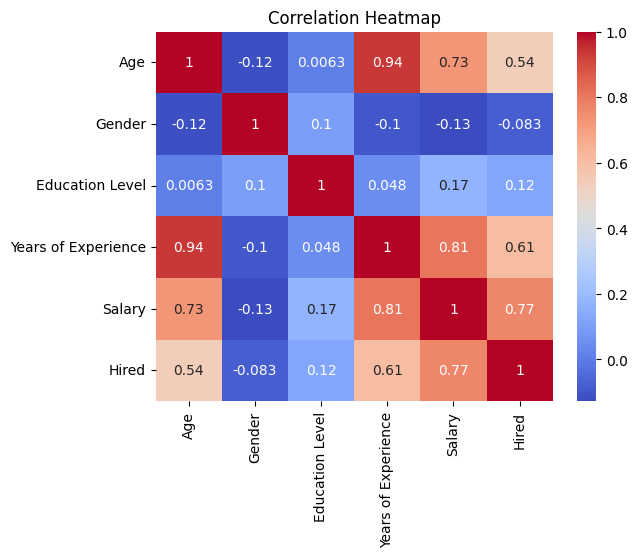

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter numeric columns only
numeric_data = data.select_dtypes(include=['number'])

# Generate the heatmap
sns.heatmap(numeric_data.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## Conclusion

This notebook demonstrates the hiring prediction pipeline, including data processing, correlation analysis, logistic regression modeling, and probabilistic reasoning. Further refinements can improve model accuracy and insights.